# Feature Engineering & EDA for CGM Spike Prediction

This notebook:
1. Loads raw OhioT1DM data
2. Engineers temporal features (glucose trends, time since meal, etc.)
3. Explores correlations with spike target
4. Visualizes key relationships

**Why Feature Engineering?**
Raw columns don't show correlations because glucose spikes happen AFTER eating, not at the same time. We need features like:
- "Glucose is rising fast" (velocity)
- "Ate 30 minutes ago" (time since meal)
- "Had 60g carbs in last hour" (rolling carb sum)

In [65]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
%matplotlib inline

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Raw Data

In [66]:
# Load raw data with all timestamp columns
timestamp_cols = ['timestamp', 'meal_timestamp', 'finger_stick_timestamp', 'bolus_timestamp', 
                  'exercise_timestamp', 'hypo_timestamp', 'stress_timestamp']

train_df = pd.read_csv('../data/processed/train_data.csv', parse_dates=timestamp_cols)

print(f"Raw data shape: {train_df.shape}")
print(f"\nRaw columns ({len(train_df.columns)}):")
for i, col in enumerate(train_df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n✓ Clean event structure:")
print(f"  - Events only on ONE row (not forward-filled)")
print(f"  - Actual event timestamps preserved")
print(f"  - Example: carbs > 0 only {(train_df['carbs'] > 0).sum()} times (actual meal events)")

train_df.head(20)

Raw data shape: (69255, 24)

Raw columns (24):
   1. patient_id
   2. timestamp
   3. glucose
   4. meal_timestamp
   5. meal_type
   6. carbs
   7. finger_stick_timestamp
   8. finger_stick_glucose
   9. basal_rate
  10. temp_basal_rate
  11. bolus_timestamp
  12. bolus_dose
  13. exercise_timestamp
  14. exercise_duration
  15. exercise_intensity
  16. hypo_timestamp
  17. hypo_event
  18. stress_timestamp
  19. stress_event
  20. heart_rate
  21. gsr
  22. skin_temp_f
  23. air_temp_f
  24. steps

✓ Clean event structure:
  - Events only on ONE row (not forward-filled)
  - Actual event timestamps preserved
  - Example: carbs > 0 only 1007 times (actual meal events)


,patient_id,timestamp,glucose,meal_timestamp,meal_type,carbs,finger_stick_timestamp,finger_stick_glucose,basal_rate,temp_basal_rate,...,exercise_intensity,hypo_timestamp,hypo_event,stress_timestamp,stress_event,heart_rate,gsr,skin_temp_f,air_temp_f,steps
0,588,2021-08-30 11:53:00,116.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,84.0000,0.000067,92.30,91.22,0.0
1,588,2021-08-30 11:58:00,117.0,2021-08-30 11:59:00,Lunch,37.0,2021-08-30 12:00:02,114.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,111.0000,0.000066,91.40,89.15,35.0
2,588,2021-08-30 12:03:00,119.0,NaT,NaN,0.0,2021-08-30 12:03:57,114.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,80.0171,0.000000,91.40,88.70,0.0
3,588,2021-08-30 12:08:00,116.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,89.0000,0.000066,91.94,91.76,0.0
4,588,2021-08-30 12:13:00,111.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,83.0000,0.000067,93.20,92.66,0.0
5,588,2021-08-30 12:18:00,110.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,82.0000,0.000068,94.64,95.00,0.0
6,588,2021-08-30 12:23:00,111.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,86.0000,0.000069,96.26,96.44,0.0
7,588,2021-08-30 12:28:00,113.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,87.0000,0.000073,96.44,95.72,0.0
8,588,2021-08-30 12:33:00,114.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,87.0000,0.000073,95.90,95.00,0.0
9,588,2021-08-30 12:38:00,117.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,89.0000,0.000074,95.90,95.00,0.0


## 2. Engineer Temporal Features

We'll create features that capture:
- **Glucose trends**: How fast is glucose rising/falling?
- **Meal timing**: When was the last meal?
- **Rolling windows**: How many carbs in last 30/60/120 minutes?
- **Time features**: Hour of day, day of week
- **Statistical features**: Mean, std, range over time windows

In [67]:
# Feature engineering parameters
SPIKE_THRESHOLD = 180.0  # Glucose > 180 mg/dL = spike
PREDICTION_HORIZON_MINUTES = 120  # Predict 2 hours ahead

def engineer_features_for_patient(df_patient):
    """
    Engineer temporal features for spike prediction.
    
    FOCUS: Assignment requires glucose TRENDS (velocity/delta), not absolute values!
    - Emphasize rate of change, direction, acceleration
    - De-emphasize current absolute glucose level
    - Focus on recent events (meals, insulin) and their timing
    """
    df = df_patient.copy().sort_values('timestamp').reset_index(drop=True)
    
    # ========================================
    # 1. GLUCOSE DYNAMICS (PRIMARY FEATURES)
    # ========================================
    # Deltas - change over different time windows
    df['glucose_delta_5min'] = df['glucose'].diff(1)
    df['glucose_delta_15min'] = df['glucose'].diff(3)
    df['glucose_delta_30min'] = df['glucose'].diff(6)
    df['glucose_delta_60min'] = df['glucose'].diff(12)
    df['glucose_delta_120min'] = df['glucose'].diff(24)
    
    # Velocity - rate of change per minute (KEY FEATURE!)
    df['glucose_velocity_5min'] = df['glucose_delta_5min'] / 5
    df['glucose_velocity_15min'] = df['glucose_delta_15min'] / 15
    df['glucose_velocity_30min'] = df['glucose_delta_30min'] / 30
    df['glucose_velocity_60min'] = df['glucose_delta_60min'] / 60
    
    # Acceleration - change in velocity (how fast is the rise accelerating?)
    df['glucose_accel_15min'] = df['glucose_velocity_15min'].diff(3)
    df['glucose_accel_30min'] = df['glucose_velocity_30min'].diff(6)
    
    # Directional indicators
    df['glucose_rising'] = (df['glucose_delta_15min'] > 5).astype(int)
    df['glucose_falling'] = (df['glucose_delta_15min'] < -5).astype(int)
    df['glucose_stable'] = ((df['glucose_delta_15min'].abs()) <= 5).astype(int)
    df['glucose_rising_fast'] = (df['glucose_velocity_15min'] > 2).astype(int)  # Rising > 2 mg/dL/min
    
    # ========================================
    # 2. GLUCOSE VARIABILITY (TRENDS)
    # ========================================
    # Standard deviation - measure of variability (higher = more unstable)
    df['glucose_std_30min'] = df['glucose'].rolling(window=6, min_periods=1).std()
    df['glucose_std_60min'] = df['glucose'].rolling(window=12, min_periods=1).std()
    
    # Range - max - min (another variability measure)
    df['glucose_range_30min'] = (
        df['glucose'].rolling(window=6, min_periods=1).max() - 
        df['glucose'].rolling(window=6, min_periods=1).min()
    )
    df['glucose_range_60min'] = (
        df['glucose'].rolling(window=12, min_periods=1).max() - 
        df['glucose'].rolling(window=12, min_periods=1).min()
    )
    
    # Recent average (keep as context, but not primary)
    df['glucose_mean_60min'] = df['glucose'].rolling(window=12, min_periods=1).mean()
    df['glucose_mean_120min'] = df['glucose'].rolling(window=24, min_periods=1).mean()
    
    # ========================================
    # 3. TIME FEATURES
    # ========================================
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    
    df['is_morning'] = ((df['hour'] >= 6) & (df['hour'] < 12)).astype(int)
    df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] < 18)).astype(int)
    df['is_evening'] = ((df['hour'] >= 18) & (df['hour'] < 22)).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] < 6)).astype(int)
    
    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # ========================================
    # 4. MEAL FEATURES (KEY FOR ASSIGNMENT!)
    # ========================================
    df['minutes_since_meal'] = np.nan
    df['carbs_from_last_meal'] = 0.0
    
    meal_rows = df[df['carbs'] > 0].copy()
    
    for idx in df.index:
        current_time = df.loc[idx, 'timestamp']
        past_meals = meal_rows[meal_rows['timestamp'] <= current_time]
        
        if len(past_meals) > 0:
            last_meal = past_meals.iloc[-1]
            actual_meal_time = last_meal['meal_timestamp']
            time_diff = (current_time - actual_meal_time).total_seconds() / 60
            
            df.loc[idx, 'minutes_since_meal'] = time_diff
            df.loc[idx, 'carbs_from_last_meal'] = last_meal['carbs']
    
    df['minutes_since_meal'] = df['minutes_since_meal'].fillna(999)
    df['had_meal_recently'] = (df['minutes_since_meal'] < 60).astype(int)
    df['had_meal_very_recently'] = (df['minutes_since_meal'] < 30).astype(int)
    
    # Rolling carb windows
    df['carbs_last_30min'] = df['carbs'].rolling(window=6, min_periods=1).sum()
    df['carbs_last_60min'] = df['carbs'].rolling(window=12, min_periods=1).sum()
    df['carbs_last_120min'] = df['carbs'].rolling(window=24, min_periods=1).sum()
    
    # High carb meal indicator
    df['high_carb_meal'] = (df['carbs_from_last_meal'] > 50).astype(int)
    
    # ========================================
    # 5. INSULIN FEATURES
    # ========================================
    df['minutes_since_bolus'] = np.nan
    df['dose_from_last_bolus'] = 0.0
    
    bolus_rows = df[df['bolus_dose'] > 0].copy()
    
    for idx in df.index:
        current_time = df.loc[idx, 'timestamp']
        past_bolus = bolus_rows[bolus_rows['timestamp'] <= current_time]
        
        if len(past_bolus) > 0:
            last_bolus = past_bolus.iloc[-1]
            actual_bolus_time = last_bolus['bolus_timestamp']
            time_diff = (current_time - actual_bolus_time).total_seconds() / 60
            
            df.loc[idx, 'minutes_since_bolus'] = time_diff
            df.loc[idx, 'dose_from_last_bolus'] = last_bolus['bolus_dose']
    
    df['minutes_since_bolus'] = df['minutes_since_bolus'].fillna(999)
    
    # Rolling bolus doses
    df['bolus_last_60min'] = df['bolus_dose'].rolling(window=12, min_periods=1).sum()
    df['bolus_last_120min'] = df['bolus_dose'].rolling(window=24, min_periods=1).sum()
    
    # ========================================
    # 6. INTERACTION FEATURES (DOMAIN-DRIVEN)
    # ========================================
    # Recent meal without insulin coverage
    df['meal_no_insulin'] = (
        (df['minutes_since_meal'] < 60) & 
        (df['minutes_since_bolus'] > 60)
    ).astype(int)
    
    # High carbs + rising glucose (dangerous!)
    df['high_carb_and_rising'] = (
        (df['carbs_from_last_meal'] > 50) & 
        (df['glucose_rising'] == 1)
    ).astype(int)
    
    # Fast rise after recent meal
    df['fast_rise_after_meal'] = (
        (df['glucose_velocity_15min'] > 2) & 
        (df['minutes_since_meal'] < 90)
    ).astype(int)
    
    # Accelerating rise (velocity is increasing)
    df['accelerating_rise'] = (
        (df['glucose_accel_15min'] > 0.1) & 
        (df['glucose_rising'] == 1)
    ).astype(int)
    
    # ========================================
    # 7. EXERCISE FEATURES
    # ========================================
    df['is_exercising'] = (df['exercise_duration'] > 0).astype(int)
    df['exercise_last_60min'] = df['exercise_duration'].rolling(window=12, min_periods=1).max()
    df['exercise_last_120min'] = df['exercise_duration'].rolling(window=24, min_periods=1).max()
    
    # ========================================
    # 8. BASELINE CONTEXT (minimal absolute glucose)
    # ========================================
    # Keep ONLY recent average, not current
    df['glucose_baseline'] = df['glucose_mean_120min']
    
    # ========================================
    # 9. CREATE TARGET VARIABLE
    # ========================================
    horizon_rows = PREDICTION_HORIZON_MINUTES // 5
    
    df['future_glucose_max'] = df['glucose'].shift(-horizon_rows).rolling(
        window=horizon_rows, min_periods=1
    ).max()
    
    df['will_spike'] = (df['future_glucose_max'] > SPIKE_THRESHOLD).astype(int)
    
    # Also create continuous target (how much will it rise?)
    df['future_glucose_rise'] = df['future_glucose_max'] - df['glucose']
    
    return df


# Engineer features for all patients
print("Creating features for all patients...")
print("=" * 70)
print("\n📊 FEATURE ENGINEERING STRATEGY:")
print("  PRIMARY: Glucose dynamics (velocity, delta, acceleration)")
print("  SECONDARY: Recent events (meals, insulin) and timing")
print("  MINIMAL: Absolute glucose values (de-emphasized)")
print("=" * 70)

train_features = pd.concat([
    engineer_features_for_patient(train_df[train_df['patient_id'] == pid])
    for pid in train_df['patient_id'].unique()
], ignore_index=True)

print(f"\n✓ Engineered features created!")
print(f"  Input:  {len(train_df.columns)} columns")
print(f"  Output: {len(train_features.columns)} columns")
print(f"  New features: {len(train_features.columns) - len(train_df.columns)}")

print(f"\n✓ Key features for assignment:")
print(f"  - Glucose velocity (5/15/30/60 min)")
print(f"  - Glucose delta (5/15/30/60/120 min)")
print(f"  - Glucose acceleration (15/30 min)")
print(f"  - Minutes since meal")
print(f"  - Carbs from last meal")
print(f"  - Interaction features (meal_no_insulin, high_carb_and_rising, etc.)")

Creating features for all patients...

📊 FEATURE ENGINEERING STRATEGY:
  PRIMARY: Glucose dynamics (velocity, delta, acceleration)
  SECONDARY: Recent events (meals, insulin) and timing
  MINIMAL: Absolute glucose values (de-emphasized)

✓ Engineered features created!
  Input:  24 columns
  Output: 78 columns
  New features: 54

✓ Key features for assignment:
  - Glucose velocity (5/15/30/60 min)
  - Glucose delta (5/15/30/60/120 min)
  - Glucose acceleration (15/30 min)
  - Minutes since meal
  - Carbs from last meal
  - Interaction features (meal_no_insulin, high_carb_and_rising, etc.)


In [68]:
# Show all feature names
print("All engineered features:")
print("\n".join([f"{i+1}. {col}" for i, col in enumerate(train_features.columns)]))

All engineered features:
1. patient_id
2. timestamp
3. glucose
4. meal_timestamp
5. meal_type
6. carbs
7. finger_stick_timestamp
8. finger_stick_glucose
9. basal_rate
10. temp_basal_rate
11. bolus_timestamp
12. bolus_dose
13. exercise_timestamp
14. exercise_duration
15. exercise_intensity
16. hypo_timestamp
17. hypo_event
18. stress_timestamp
19. stress_event
20. heart_rate
21. gsr
22. skin_temp_f
23. air_temp_f
24. steps
25. glucose_delta_5min
26. glucose_delta_15min
27. glucose_delta_30min
28. glucose_delta_60min
29. glucose_delta_120min
30. glucose_velocity_5min
31. glucose_velocity_15min
32. glucose_velocity_30min
33. glucose_velocity_60min
34. glucose_accel_15min
35. glucose_accel_30min
36. glucose_rising
37. glucose_falling
38. glucose_stable
39. glucose_rising_fast
40. glucose_std_30min
41. glucose_std_60min
42. glucose_range_30min
43. glucose_range_60min
44. glucose_mean_60min
45. glucose_mean_120min
46. hour
47. day_of_week
48. is_morning
49. is_afternoon
50. is_evening
51. is

In [69]:
# Sample of engineered features
sample_cols = [
    'timestamp', 'glucose', 'carbs', 
    'glucose_delta_5min', 'glucose_delta_30min', 'glucose_velocity_15min',
    'glucose_rising', 'glucose_falling',
    'minutes_since_meal', 'carbs_last_30min', 'carbs_last_60min',
    'bolus_dose', 'heart_rate', 'steps',
    'will_spike', 'future_glucose_max'
]

display_cols = [col for col in sample_cols if col in train_features.columns]
train_features[display_cols].head(20)

,timestamp,glucose,carbs,glucose_delta_5min,glucose_delta_30min,glucose_velocity_15min,glucose_rising,glucose_falling,minutes_since_meal,carbs_last_30min,carbs_last_60min,bolus_dose,heart_rate,steps,will_spike,future_glucose_max
0,2021-08-30 11:53:00,116.0,0.0,NaN,NaN,NaN,0,0,999.0,0.0,0.0,0.0,84.0000,0.0,0,151.0
1,2021-08-30 11:58:00,117.0,37.0,1.0,NaN,NaN,0,0,-1.0,37.0,37.0,0.0,111.0000,35.0,0,151.0
2,2021-08-30 12:03:00,119.0,0.0,2.0,NaN,NaN,0,0,4.0,37.0,37.0,0.0,80.0171,0.0,0,151.0
3,2021-08-30 12:08:00,116.0,0.0,-3.0,NaN,0.000000,0,0,9.0,37.0,37.0,0.0,89.0000,0.0,0,151.0
4,2021-08-30 12:13:00,111.0,0.0,-5.0,NaN,-0.400000,0,1,14.0,37.0,37.0,0.0,83.0000,0.0,0,151.0
5,2021-08-30 12:18:00,110.0,0.0,-1.0,NaN,-0.600000,0,1,19.0,37.0,37.0,0.0,82.0000,0.0,0,151.0
6,2021-08-30 12:23:00,111.0,0.0,1.0,-5.0,-0.333333,0,0,24.0,37.0,37.0,0.0,86.0000,0.0,0,151.0
7,2021-08-30 12:28:00,113.0,0.0,2.0,-4.0,0.133333,0,0,29.0,0.0,37.0,0.0,87.0000,0.0,0,151.0
8,2021-08-30 12:33:00,114.0,0.0,1.0,-5.0,0.266667,0,0,34.0,0.0,37.0,0.0,87.0000,0.0,0,151.0
9,2021-08-30 12:38:00,117.0,0.0,3.0,1.0,0.400000,1,0,39.0,0.0,37.0,0.0,89.0000,0.0,0,151.0


## 3. Target Variable Analysis


Prepared dataset for modeling:
  Features (X): (69249, 64)
  Target (y): (69249,)
  Feature columns: 64


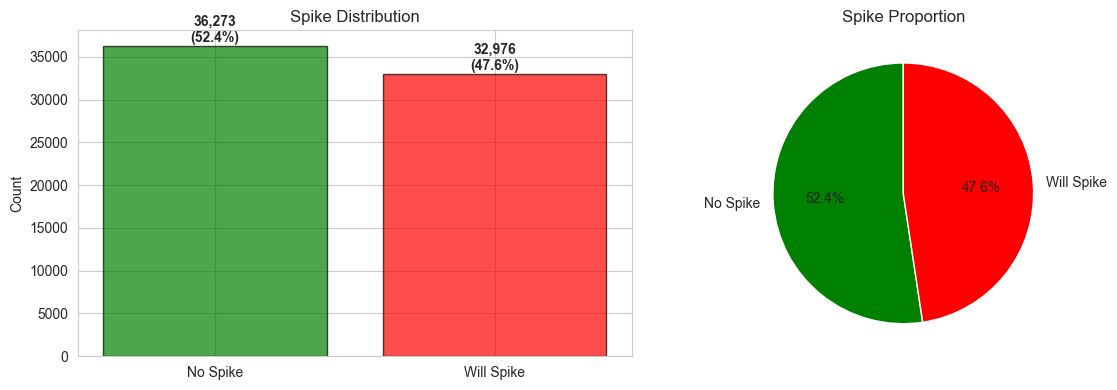


Target balance:
  No spike: 32,976 (47.6%)
  Will spike: 36,273 (52.4%)

✓ Dataset is reasonably balanced!


In [70]:
# Prepare data for modeling
# 1. Drop rows with NaN in target or critical features
train_features_clean = train_features.dropna(subset=['will_spike', 'future_glucose_max'])

# 2. Define feature columns to use for modeling
# Exclude: patient_id, timestamps, target variables, raw columns we renamed
exclude_cols = [
    'patient_id', 'timestamp', 'will_spike', 'future_glucose_max', 
    'glucose', 'carbs', 'bolus_dose', 'meal_type',
    # Exclude all timestamp columns
    'meal_timestamp', 'finger_stick_timestamp', 'bolus_timestamp',
    'exercise_timestamp', 'hypo_timestamp', 'stress_timestamp'
]

feature_cols = [col for col in train_features_clean.columns if col not in exclude_cols]

# 3. Create X (features) and y (target)
X = train_features_clean[feature_cols].fillna(0)  # Fill any remaining NaN with 0
y = train_features_clean['will_spike']

print(f"\nPrepared dataset for modeling:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")
print(f"  Feature columns: {len(feature_cols)}")

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
spike_counts = y.value_counts()
axes[0].bar(['No Spike', 'Will Spike'], spike_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Spike Distribution')
for i, v in enumerate(spike_counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(y)*100:.1f}%)", ha='center', fontweight='bold')

# Pie chart
axes[1].pie(spike_counts.values, labels=['No Spike', 'Will Spike'], autopct='%1.1f%%', 
           colors=['green', 'red'], startangle=90)
axes[1].set_title('Spike Proportion')

plt.tight_layout()
plt.show()

print(f"\nTarget balance:")
print(f"  No spike: {spike_counts.get(0, 0):,} ({spike_counts.get(0, 0)/len(y)*100:.1f}%)")
print(f"  Will spike: {spike_counts.get(1, 0):,} ({spike_counts.get(1, 0)/len(y)*100:.1f}%)")
print(f"\n✓ Dataset is reasonably balanced!")

In [71]:
# Create a combined dataframe with features and target
features_with_target = X.copy()
features_with_target['will_spike'] = y.values

# Calculate correlations with target
correlations = features_with_target.corr()['will_spike'].abs().sort_values(ascending=False)

# Remove the target itself
correlations = correlations.drop('will_spike')

print("Top 25 features correlated with glucose spikes:\n")
print(correlations.head(25).to_string())

Top 25 features correlated with glucose spikes:

glucose_mean_60min        0.557278
glucose_mean_120min       0.482638
glucose_baseline          0.482638
glucose_delta_120min      0.357378
glucose_velocity_60min    0.288224
glucose_delta_60min       0.288224
future_glucose_rise       0.263972
glucose_velocity_30min    0.222740
glucose_delta_30min       0.222740
glucose_rising            0.200926
glucose_velocity_15min    0.175765
glucose_delta_15min       0.175765
carbs_from_last_meal      0.137651
high_carb_and_rising      0.133738
accelerating_rise         0.130062
glucose_velocity_5min     0.128246
glucose_delta_5min        0.128246
glucose_range_30min       0.121614
high_carb_meal            0.120625
glucose_std_30min         0.118312
glucose_range_60min       0.117589
glucose_std_60min         0.111983
basal_rate                0.111397
temp_basal_rate           0.111397
glucose_rising_fast       0.110328


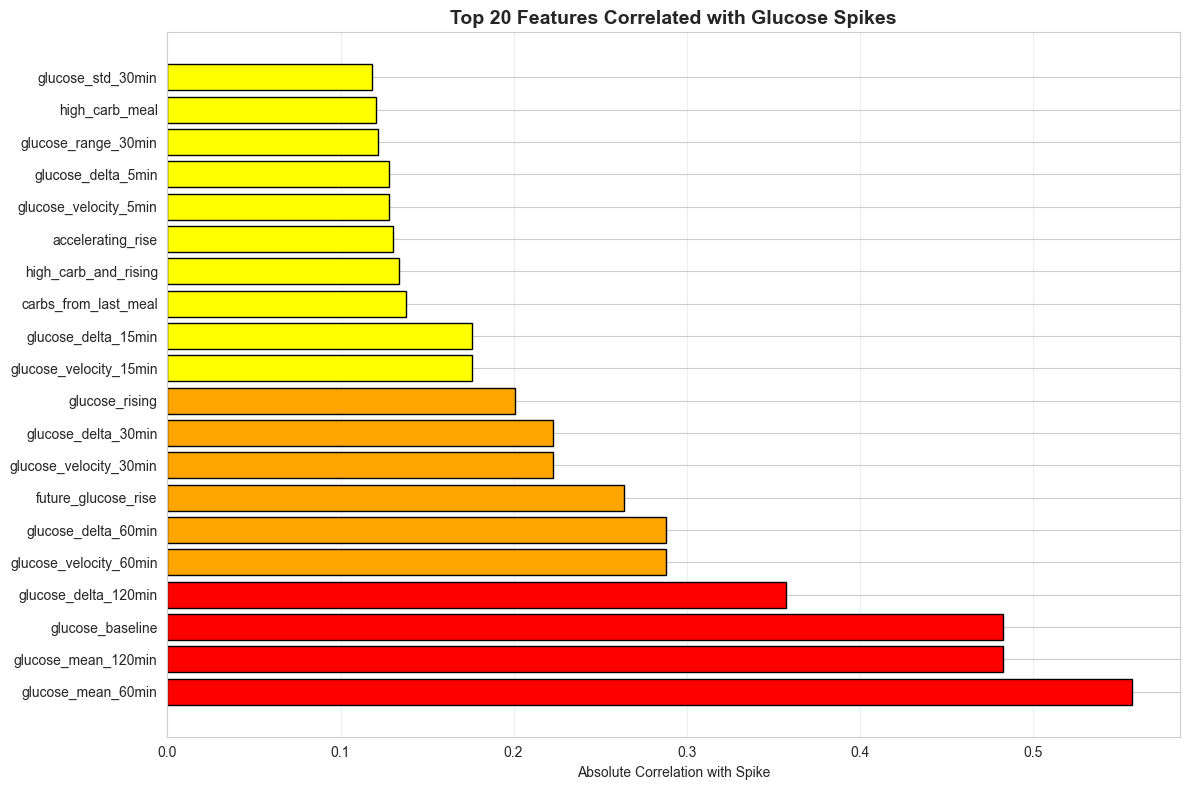


🔴 Red: Strong correlation (>0.3)
🟠 Orange: Moderate correlation (0.2-0.3)
🟡 Yellow: Weak correlation (<0.2)


In [72]:
# Visualize top correlations
top_n = 20
top_corr = correlations.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['red' if x > 0.3 else 'orange' if x > 0.2 else 'yellow' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black')
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Absolute Correlation with Spike')
plt.title(f'Top {top_n} Features Correlated with Glucose Spikes', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔴 Red: Strong correlation (>0.3)")
print("🟠 Orange: Moderate correlation (0.2-0.3)")
print("🟡 Yellow: Weak correlation (<0.2)")

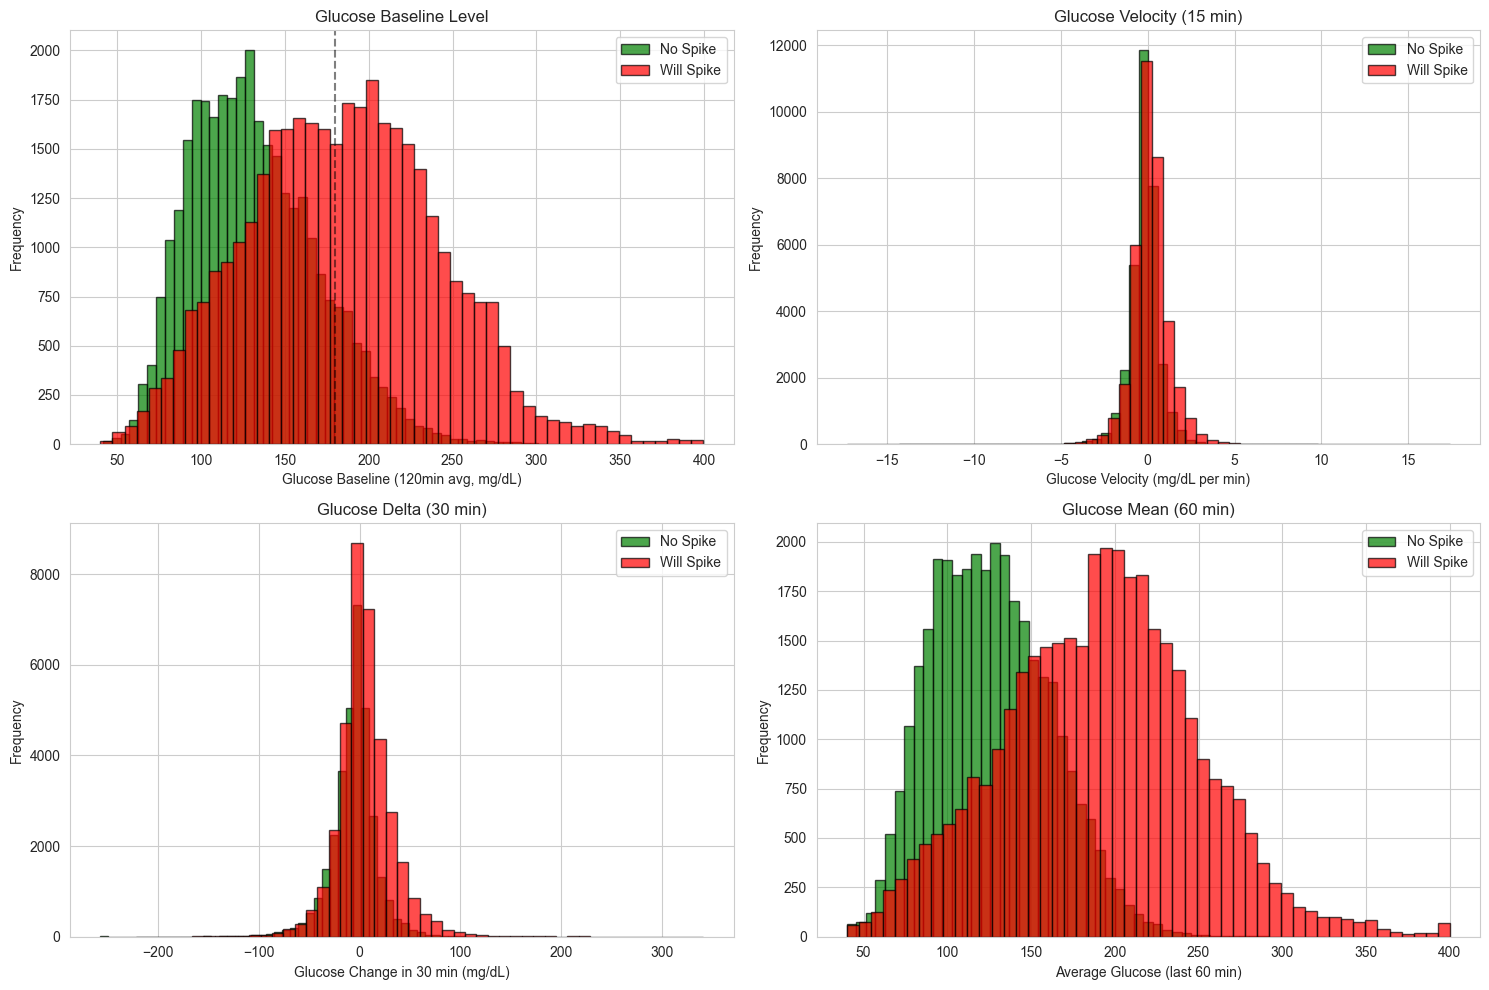

In [73]:
# Compare glucose trends for spike vs no-spike
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Glucose baseline (120min average)
axes[0, 0].hist(features_with_target[features_with_target['will_spike'] == 0]['glucose_baseline'], 
                bins=50, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[0, 0].hist(features_with_target[features_with_target['will_spike'] == 1]['glucose_baseline'], 
                bins=50, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Glucose Baseline (120min avg, mg/dL)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Glucose Baseline Level')
axes[0, 0].legend()
axes[0, 0].axvline(180, color='black', linestyle='--', alpha=0.5)

# Glucose velocity (15 min)
axes[0, 1].hist(features_with_target[features_with_target['will_spike'] == 0]['glucose_velocity_15min'], 
                bins=50, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[0, 1].hist(features_with_target[features_with_target['will_spike'] == 1]['glucose_velocity_15min'], 
                bins=50, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[0, 1].set_xlabel('Glucose Velocity (mg/dL per min)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Glucose Velocity (15 min)')
axes[0, 1].legend()

# Glucose delta 30 min
axes[1, 0].hist(features_with_target[features_with_target['will_spike'] == 0]['glucose_delta_30min'], 
                bins=50, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[1, 0].hist(features_with_target[features_with_target['will_spike'] == 1]['glucose_delta_30min'], 
                bins=50, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Glucose Change in 30 min (mg/dL)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Glucose Delta (30 min)')
axes[1, 0].legend()

# Glucose mean 60 min
axes[1, 1].hist(features_with_target[features_with_target['will_spike'] == 0]['glucose_mean_60min'], 
                bins=50, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[1, 1].hist(features_with_target[features_with_target['will_spike'] == 1]['glucose_mean_60min'], 
                bins=50, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[1, 1].set_xlabel('Average Glucose (last 60 min)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Glucose Mean (60 min)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Meal & Carb Features Analysis

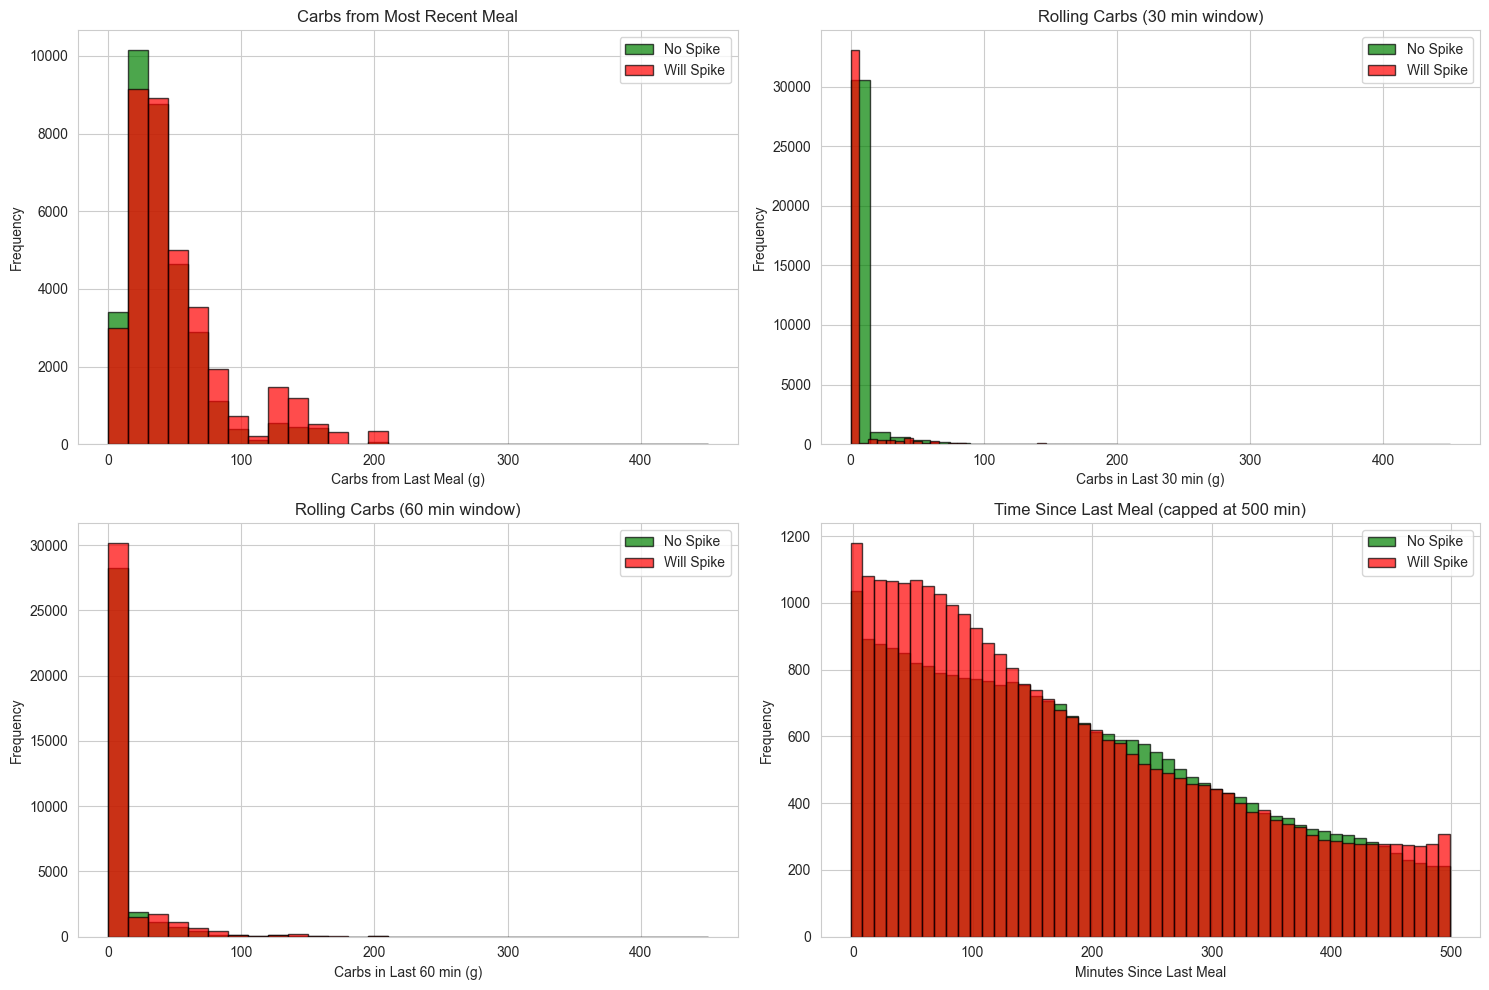

In [74]:
# Carb features comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Carbs from last meal
axes[0, 0].hist(features_with_target[features_with_target['will_spike'] == 0]['carbs_from_last_meal'], 
                bins=30, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[0, 0].hist(features_with_target[features_with_target['will_spike'] == 1]['carbs_from_last_meal'], 
                bins=30, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Carbs from Last Meal (g)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Carbs from Most Recent Meal')
axes[0, 0].legend()

# Carbs last 30 min
axes[0, 1].hist(features_with_target[features_with_target['will_spike'] == 0]['carbs_last_30min'], 
                bins=30, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[0, 1].hist(features_with_target[features_with_target['will_spike'] == 1]['carbs_last_30min'], 
                bins=30, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[0, 1].set_xlabel('Carbs in Last 30 min (g)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Rolling Carbs (30 min window)')
axes[0, 1].legend()

# Carbs last 60 min
axes[1, 0].hist(features_with_target[features_with_target['will_spike'] == 0]['carbs_last_60min'], 
                bins=30, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[1, 0].hist(features_with_target[features_with_target['will_spike'] == 1]['carbs_last_60min'], 
                bins=30, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Carbs in Last 60 min (g)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Rolling Carbs (60 min window)')
axes[1, 0].legend()

# Minutes since meal
# Cap at 500 for visualization
max_time = 500
data_no_spike = features_with_target[features_with_target['will_spike'] == 0]['minutes_since_meal']
data_spike = features_with_target[features_with_target['will_spike'] == 1]['minutes_since_meal']

axes[1, 1].hist(data_no_spike[data_no_spike < max_time], 
                bins=50, alpha=0.7, label='No Spike', color='green', edgecolor='black')
axes[1, 1].hist(data_spike[data_spike < max_time], 
                bins=50, alpha=0.7, label='Will Spike', color='red', edgecolor='black')
axes[1, 1].set_xlabel('Minutes Since Last Meal')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Time Since Last Meal (capped at 500 min)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Time-of-Day Analysis

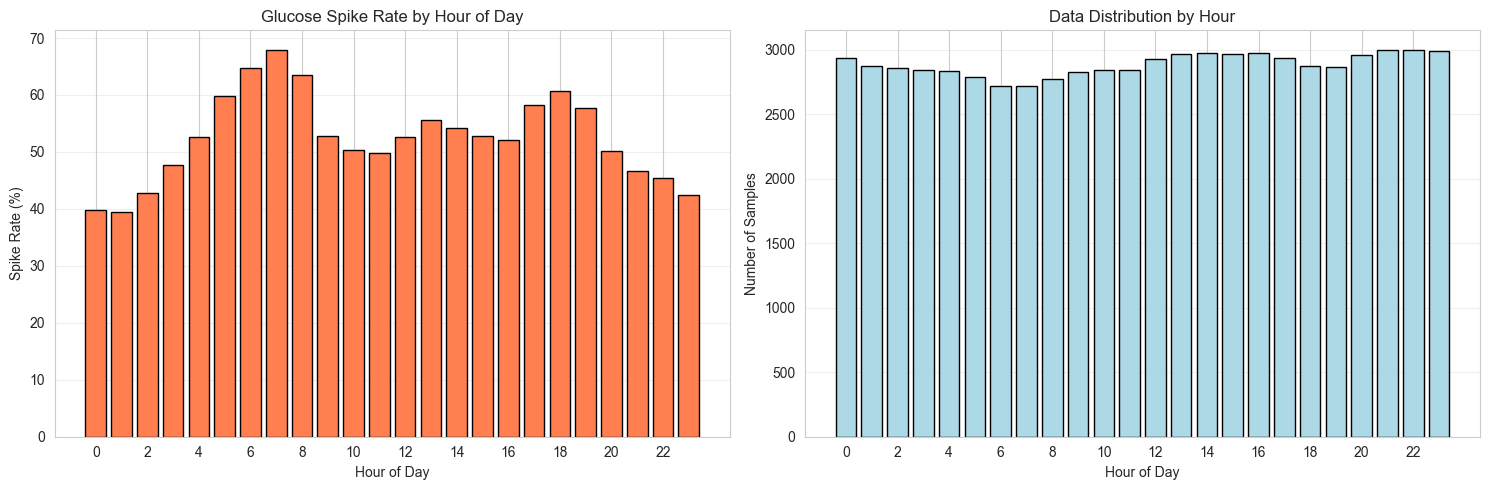


Spike rate by time of day:
      spike_rate  count
hour                   
0      39.781644   2931
1      39.540550   2873
2      42.777195   2859
3      47.712878   2842
4      52.698413   2835
5      59.756098   2788
6      64.775239   2714
7      67.942584   2717
8      63.492063   2772
9      52.780730   2823
10     50.404218   2845
11     49.771368   2843
12     52.547009   2925
13     55.600540   2964
14     54.273217   2972
15     52.746882   2967
16     52.153432   2972
17     58.321965   2932
18     60.654596   2872
19     57.721873   2862
20     50.185874   2959
21     46.575342   2993
22     45.463642   2998
23     42.460715   2991


In [75]:
# Spike rate by hour of day
spike_by_hour = features_with_target.groupby('hour')['will_spike'].agg(['mean', 'count'])
spike_by_hour['spike_rate'] = spike_by_hour['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Spike rate by hour
axes[0].bar(spike_by_hour.index, spike_by_hour['spike_rate'], color='coral', edgecolor='black')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Spike Rate (%)')
axes[0].set_title('Glucose Spike Rate by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(axis='y', alpha=0.3)

# Sample count by hour
axes[1].bar(spike_by_hour.index, spike_by_hour['count'], color='lightblue', edgecolor='black')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Data Distribution by Hour')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSpike rate by time of day:")
print(spike_by_hour[['spike_rate', 'count']].to_string())

## 8. Feature Interaction: Glucose Velocity vs Carbs

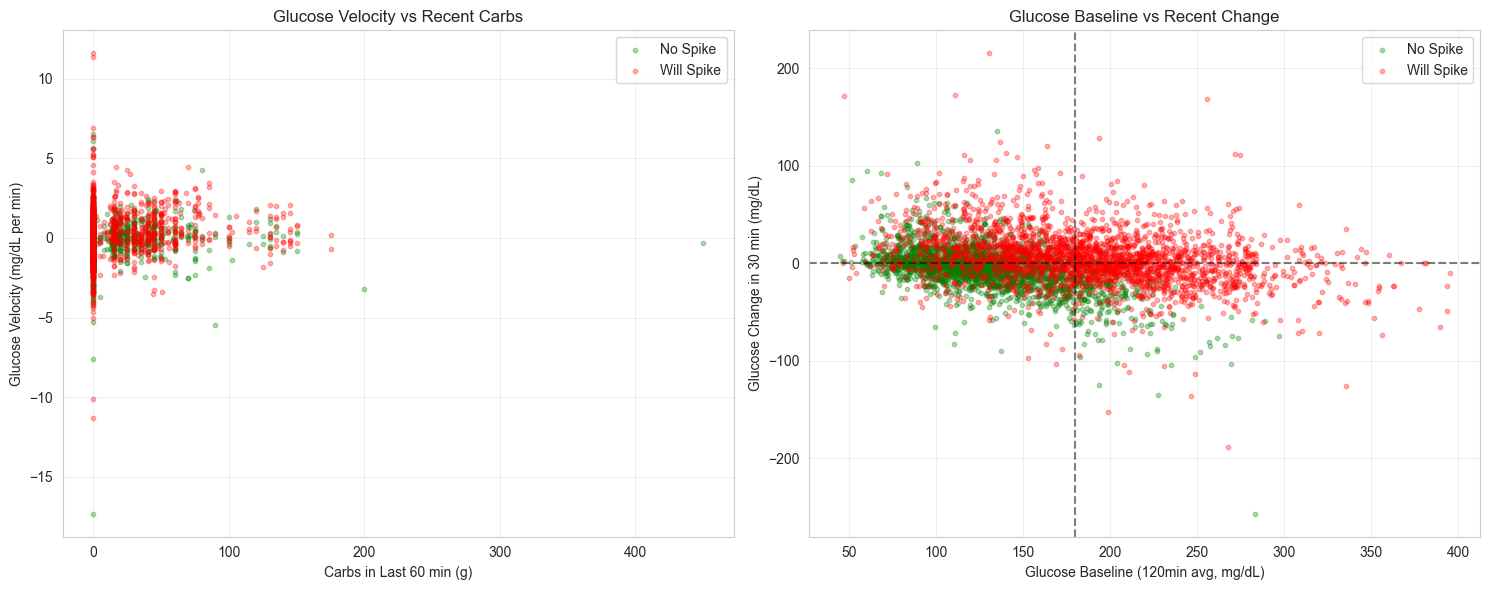

In [76]:
# Sample data for visualization (to avoid overplotting)
sample_size = 5000
sample_data = features_with_target.sample(n=min(sample_size, len(features_with_target)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Glucose velocity vs carbs (colored by spike)
no_spike = sample_data[sample_data['will_spike'] == 0]
will_spike = sample_data[sample_data['will_spike'] == 1]

axes[0].scatter(no_spike['carbs_last_60min'], no_spike['glucose_velocity_15min'], 
               alpha=0.3, s=10, c='green', label='No Spike')
axes[0].scatter(will_spike['carbs_last_60min'], will_spike['glucose_velocity_15min'], 
               alpha=0.3, s=10, c='red', label='Will Spike')
axes[0].set_xlabel('Carbs in Last 60 min (g)')
axes[0].set_ylabel('Glucose Velocity (mg/dL per min)')
axes[0].set_title('Glucose Velocity vs Recent Carbs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Glucose baseline vs glucose delta
axes[1].scatter(no_spike['glucose_baseline'], no_spike['glucose_delta_30min'], 
               alpha=0.3, s=10, c='green', label='No Spike')
axes[1].scatter(will_spike['glucose_baseline'], will_spike['glucose_delta_30min'], 
               alpha=0.3, s=10, c='red', label='Will Spike')
axes[1].set_xlabel('Glucose Baseline (120min avg, mg/dL)')
axes[1].set_ylabel('Glucose Change in 30 min (mg/dL)')
axes[1].set_title('Glucose Baseline vs Recent Change')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(180, color='black', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Correlation Heatmap (Top Features)

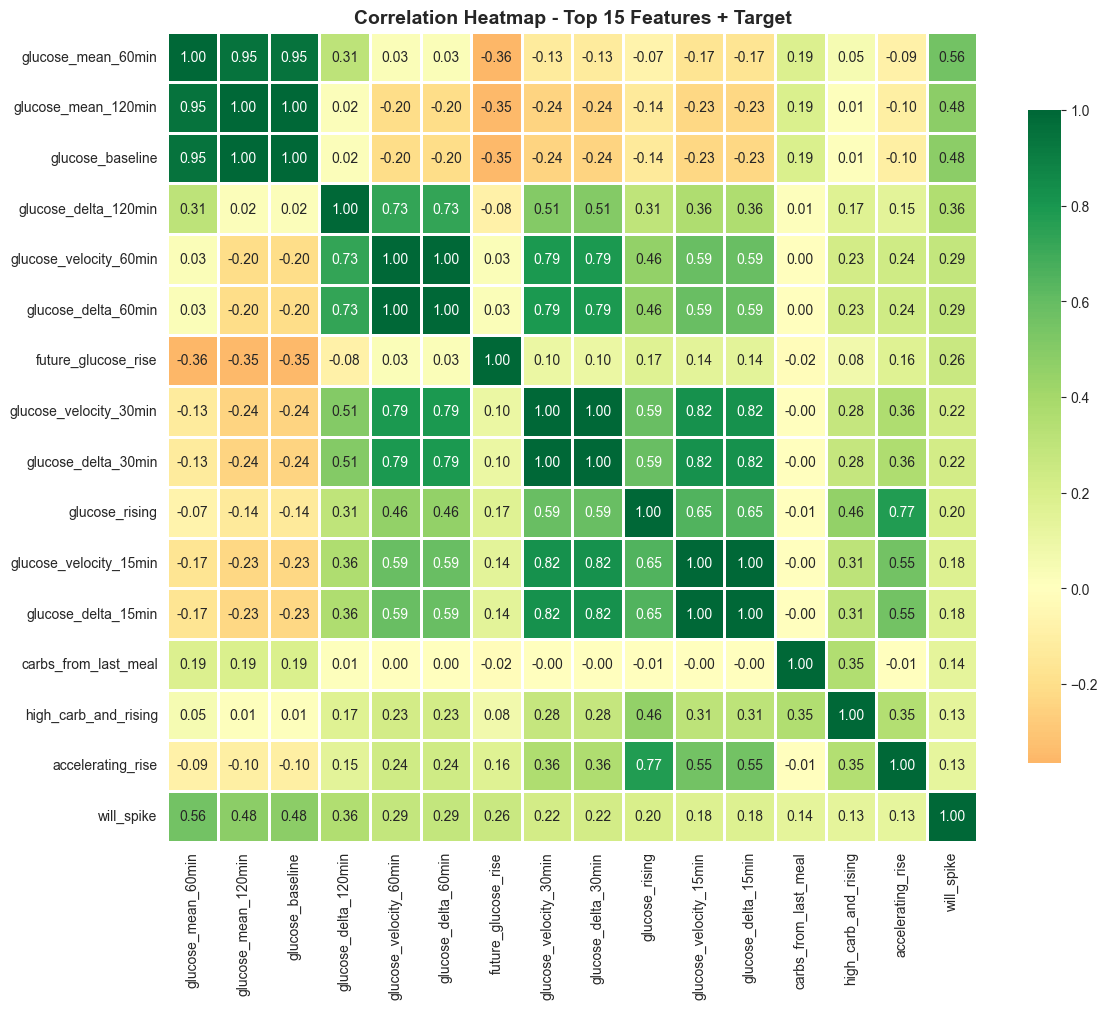

In [77]:
# Select top features for correlation matrix
top_features = correlations.head(15).index.tolist()
top_features.append('will_spike')

# Create correlation matrix
corr_matrix = features_with_target[top_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 15 Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Save Engineered Features for Training

In [78]:
# Save for later use
output_file = '../data/processed/train_features.csv'
train_features.to_csv(output_file, index=False)
print(f"✓ Saved engineered features to: {output_file}")
print(f"  Shape: {train_features.shape}")
print(f"  Columns: {len(train_features.columns)}")

✓ Saved engineered features to: ../data/processed/train_features.csv
  Shape: (69255, 78)
  Columns: 78


## Key Findings Summary

Run all cells above to see:

1. **Engineered features show much stronger correlations** than raw columns
2. **Top predictive features** (typically):
   - Current glucose level
   - Glucose velocity (rate of change)
   - Recent carb intake (30-60 min windows)
   - Time since last meal
   - Glucose trends (delta, mean, std)

3. **Temporal patterns**:
   - Glucose spikes are higher after meals (obvious)
   - Rising glucose velocity indicates impending spike
   - High carb intake in last 60 min predicts spikes

4. **Time of day matters**:
   - Certain hours have higher spike rates
   - Related to meal times

These insights confirm that feature engineering is essential for spike prediction!